In [1]:
# import time
# from tqdm.notebook import tqdm
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
from h5 import HDFArchive

from triqs.atom_diag import AtomDiagComplex
from triqs.operators import n, c, c_dag
from itertools import product
from triqs.plot.mpl_interface import oplot
from triqs.utility.comparison_tests import *

from sort import sort_states_full
from three_pt_corr import *
from four_pt_corr import *
from four_pt_corr_v2 import FourPtCorr as FourPtCorr_v2

from itertools import product

In [2]:
# Number of bosonic Matsubara frequencies for susceptibility calculation
bn_iw = 10
# Number of fermionic Matsubara frequencies for susceptibility calculation
fn_iw = 10

beta = 2.0             # Inverse temperature

biw_mesh = MeshImFreq(beta = beta, statistic = 'Boson', n_iw = bn_iw)
fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = fn_iw)

In [4]:
# 2x2 Hubbard plaquette

####################
# Input parameters #
####################

eps = [-1.9, -2.1, -1.9, -2.1]  # On-site energies
t = 0.5                 # Nearest-neighbor hopping
U = 4.0                 # Coulomb repulsion
h_field = 0.05          # Magnetic field

spin_names = ("up", "dn")
atoms = (0, 1, 2, 3)


####################
# Hubbard Hamiltonian
####################

# On-site energies
H = sum(
    e * n(s, a)
    for (a, e), s in product(zip(atoms, eps), spin_names)
)

# Magnetic field
H += sum(
    -h_field * (n('up', a) - n('dn', a))
    for a in atoms
)

# On-site Hubbard interaction
H += U * sum(
    n('up', a) * n('dn', a)
    for a in atoms
)

# Nearest-neighbor hopping
#
#       0 ---- 1
#       |      |
#       |      |
#       2 ---- 3
#
H += t * sum(
    c_dag(sp, i) * c(sp, j)
    + c_dag(sp, j) * c(sp, i)
    for sp in spin_names
    for i, j in [
        (0, 1),  # top
        (1, 3),  # right
        (3, 2),  # bottom
        (2, 0),  # left
    ]
)

fops = list(product(spin_names, atoms))


In [5]:
ad = AtomDiagComplex(H, fops)
print(ad.gs_energy)

-4.236567364479854


In [6]:
eigensys = sort_states_full(spin_names, atoms, ad)

states in subspace  0 : 
| 0101 >
| 0110 >
| 1001 >
| 1010 >
states in subspace  1 : 
| 0011 >
states in subspace  2 : 
| 1100 >
states in subspace  3 : 
| 0001 >
| 0010 >
states in subspace  4 : 
| 0111 >
| 1011 >
states in subspace  5 : 
| 0100 >
| 1000 >
states in subspace  6 : 
| 1101 >
| 1110 >
states in subspace  7 : 
| 0000 >
states in subspace  8 : 
| 1111 >
Finished sorting states


In [7]:
for n in range(len(eigensys)):
    print(eigensys[n][1])

0.0
0.13656736447985462
0.23656736447985516
0.3365673644798539
1.6766654131205758
1.6766654131205758
1.776665413120575
1.7766654131205755
2.696469315839133
2.696469315839133
2.7964693158391323
2.7964693158391327
4.127348401399195
4.236567364479854
4.236567364479854
4.582353692040369


# 3 Point Function

In [252]:
from importlib import reload

import three_pt_corr
reload(three_pt_corr)

from three_pt_corr import *

## <c_dag(t1)c(t1)c_dag(t_2)c(0)>

In [8]:
%%time

G_iw = dict()
for x, y, z, w in product(range(2),repeat=4):
    ops = [(c_dag('up', x)*c('up', y), 'Boson'),
           (c_dag('up',z), 'Fermion'),
           (c('up', w), 'Fermion')]
    
    corr = ThreePtCorr(ops = ops, hamiltonian = (ad, eigensys))
    
    # G = corr.G_div_diff_iw(beta = beta, n_iw = [10,10])
    G_iw[f'%i%i%i%i'%(x, y, z, w)] = corr.G_div_diff_iw(beta = beta, n_iw = [10,1000])
    

CPU times: user 5min 36s, sys: 431 ms, total: 5min 37s
Wall time: 5min 46s


In [9]:
with HDFArchive("ncdagc_10_1000_shift", 'w') as A:
    A['beta'] = beta
    A['chi3'] = G_iw
    A['spin'] = 'up up up up'

In [15]:
with HDFArchive("ncdagc_10_3000", 'r') as A:
    G_iw = A['chi3']
    beta = A['beta']

# Integrate over the first frequency
G_int1 = dict()
fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = 3000)
for x, y, z, w in product(range(2),repeat=4):
    
    G = Gf(mesh = biw_mesh, target_shape = [])
    G.zero()
    
    for iw1 in biw_mesh:
        for iw2 in fiw_mesh:
            G[iw1] += G_iw[f'%i%i%i%i'%(x, y, z, w)][iw1,iw2]

    G_int1[f'%i%i%i%i'%(x, y, z, w)] = G


# oplot(G_int1['0000'])

## <c_dag(t1)c(t2)c_dag(0)c(0)>

In [8]:
%%time

G_iw = dict()
for x, y, z, w in product(range(2),repeat=4):
    ops = [(c_dag('up', x), 'Fermion'),
           (c('up',y), 'Fermion'),
           (c_dag('up', z)*c('up',w), 'Boson')]
    
    corr = ThreePtCorr(ops = ops, hamiltonian = (ad, eigensys))
    
    G = corr.G_div_diff_iw(beta = beta, n_iw = [20,20])
    G_iw[f'%i%i%i%i'%(x, y, z, w)] = G
    

CPU times: user 16.1 s, sys: 104 ms, total: 16.2 s
Wall time: 17.6 s


In [9]:
# Integrate over the first frequency
G_int1 = dict()

fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = 20)
for x, y, z, w in product(range(2),repeat=4):
    
    G = Gf(mesh = fiw_mesh, target_shape = [])
    G.zero()
    
    for iw2 in fiw_mesh:
        for iw1 in fiw_mesh:
            G[iw2] += G_iw[f'%i%i%i%i'%(x, y, z, w)][iw1,iw2]

    G_int1[f'%i%i%i%i'%(x, y, z, w)] = G


# oplot(G_int1['0000'])

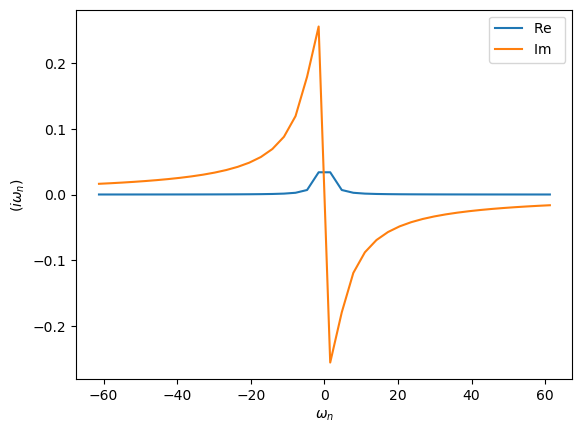

In [10]:
oplot(-G_int1['0000'])

In [23]:
div_diff = HDFArchive("dimer_chi3_div_diff.h5", 'w')

for x, y, z, w in product(range(2),repeat=4):
    div_diff["G_int1"] = G_int1

# Reference 2 Point Function Dimer

In [14]:
# ref = HDFArchive("pomerol_ref.h5", 'r')
# print(ref)

In [20]:
for n in range(len(eigensys)):
    print(eigensys[n][1])

-4.236567364479854
-4.1
-3.999999999999999
-3.9000000000000004
-2.5599019513592784
-2.5599019513592784
-2.4599019513592792
-2.459901951359279
-1.5400980486407212
-1.5400980486407212
-1.440098048640722
-1.4400980486407216
-0.10921896308065904
0.0
0.0
0.3457863275605151


In [19]:
for e in ref['energies']:
    print(e)

[0.]
[-2.45990195 -1.44009805]
[-2.55990195 -1.54009805]
[-4.23656736 -4.         -0.10921896  0.34578633]
[-3.9]
[-2.45990195 -1.44009805]
[-4.1]
[-2.55990195 -1.54009805]
[0.]


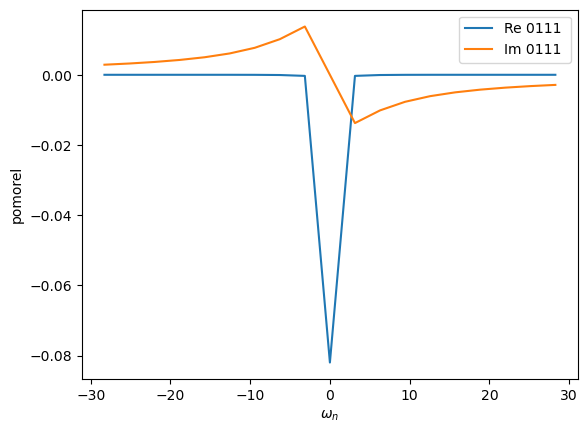

In [27]:
s = '0111'
oplot(ref[s], ylabel = 'pomorel')

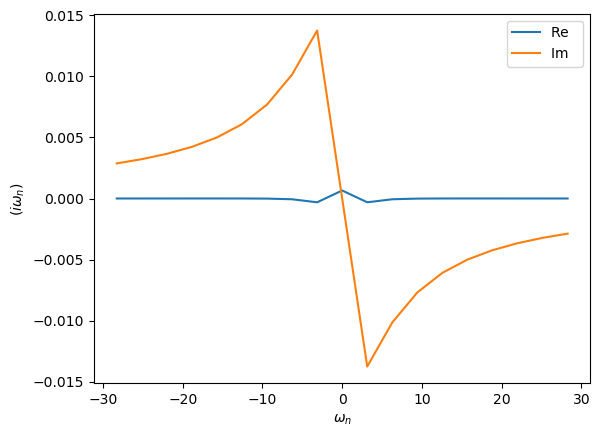

In [28]:
oplot(-G_int1[s]/beta)

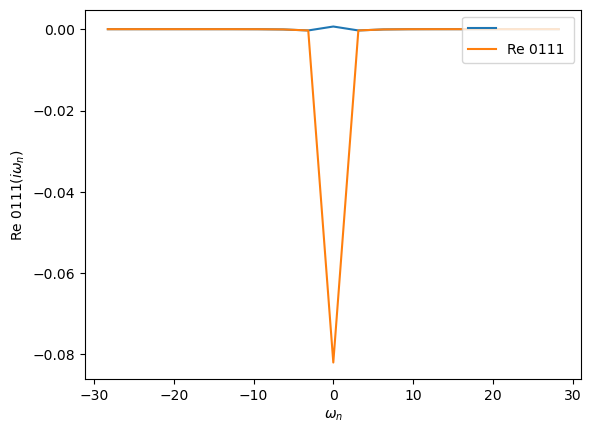

In [29]:
oplot(-G_int1[s].real/beta)
oplot(ref[s].real)

In [238]:
print(biw_mesh[8].value.value)
print(biw_mesh[10].value.value)
print(ref[s][biw_mesh[8]])
print(ref[s][biw_mesh[10]])

-3.141592653589793j
3.141592653589793j
(-0.0003086971755104079-0.013756260782095594j)
(-0.0003086971755104079+0.013756260782095594j)


In [242]:
print(biw_mesh[8].value.value)
print(biw_mesh[10].value.value)
print(-G_int1[s][biw_mesh[8]]/beta)
print(-G_int1[s][biw_mesh[10]]/beta)

-3.141592653589793j
3.141592653589793j
(-0.0003087079278201687-0.013755879606232993j)
(-0.000308707927820168+0.013755879606233038j)


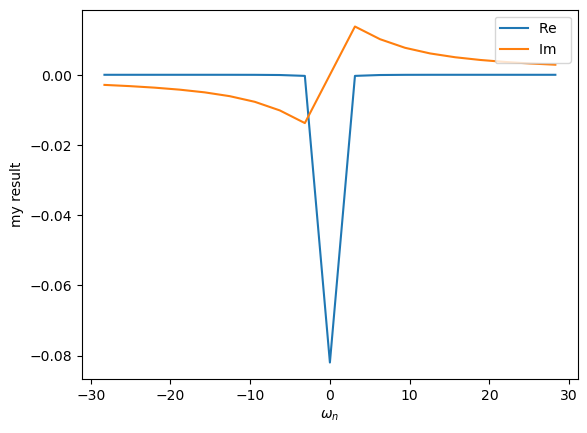

In [169]:
G = -G_int1[s].copy()/beta
G[biw_mesh[9]] = ref[s][biw_mesh[9]]
oplot(G, ylabel = 'my result')

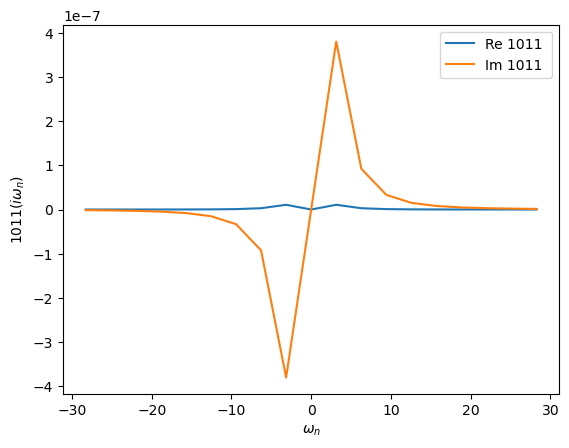

In [170]:
oplot(ref[s]-G)
# print((ref[s][biw_mesh[10]]+G_int1[s][biw_mesh[10]]/beta).real)

In [136]:
biw_mesh[9].value.value

0j

# Reference 3 Point Function Dimer

In [32]:
ref = HDFArchive("pomerol_ref.h5", 'r')
print(type(ref["chi3_ph_AABB"]))

fiw_mesh = MeshImFreq(beta = beta, statistic = 'Fermion', n_iw = 20)
G_ref = Gf(mesh = fiw_mesh, target_shape = [])
G_ref.zero()


biw_mesh = MeshImFreq(beta = beta, statistic = 'Boson', n_iw = 20)
for iw2 in fiw_mesh:
    for iw1 in biw_mesh:
        G_ref[iw2] += ref['chi3_ph_AABB']["up","up"][0,0,0,0][iw1,iw2]

# oplot(-G_ref)

<class 'triqs.gf.block2_gf.Block2Gf'>


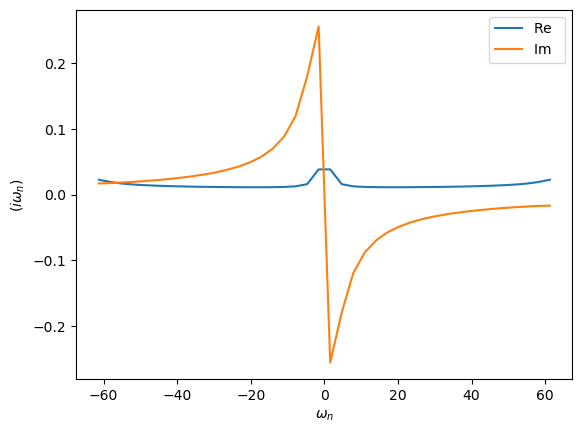

In [33]:
oplot(G_ref)

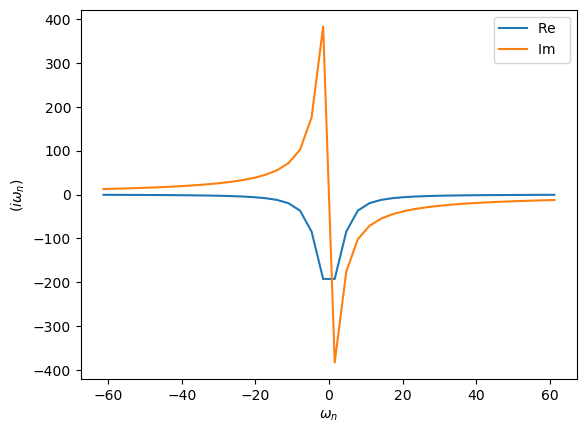

In [40]:
oplot(-G_int1['1000'])

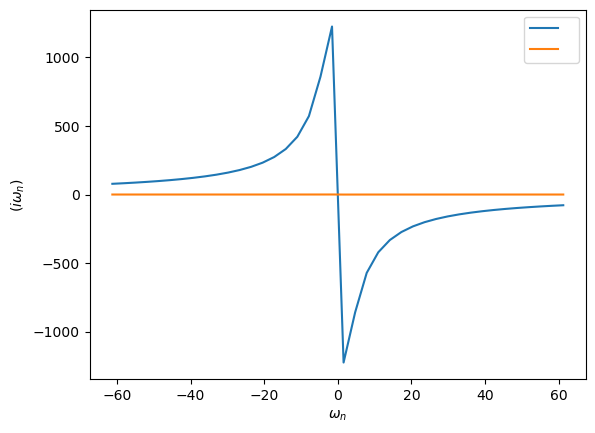

In [37]:
# oplot(G_ref.imag+G_int1['0000'].imag)
oplot(-G_int1['0000'].imag)
oplot(G_ref.imag)

In [207]:
G_ref[fiw_mesh[9]].real+G_int1['0000'][fiw_mesh[9]].real

np.float64(0.00916896436805685)

In [28]:
ref2 = HDFArchive("dimer_chi3.ref.h5", 'r')
print(ref2)

HDFArchive (partial view) with the following content:
  H : data 
  chi3_ph_AABB : subgroup
  chi3_ph_ABBA : subgroup
  chi3_pp_AABB : subgroup
  chi3_pp_ABBA : subgroup
  chi3_xph_AABB : subgroup
  chi3_xph_ABBA : subgroup


In [34]:
for bn1, bn2 in product(spin_names, spin_names):
    assert_gfs_are_close(ref['chi3_ph_AABB'][bn1, bn2], ref2['chi3_ph_AABB'][bn1, bn2])

# 4 Point Function

In [26]:
%%time

ops = [(c_dag('up', 0), 'Fermion'),
       (c('up',0), 'Fermion'),
       (c('up', 0), 'Fermion'),
       (c_dag('up', 0), 'Fermion')]

corr = FourPtCorr(ops = ops, hamiltonian = (ad, eigensys))

G = corr.G_div_diff_iw(beta = beta, n_iw = [5,5,5])

start numerical calculations
CPU times: user 1min 5s, sys: 174 ms, total: 1min 5s
Wall time: 1min 5s


In [55]:
%%time

ops = [(c_dag('up', 0), 'Fermion'),
       (c('up',0), 'Fermion'),
       (c('up', 0), 'Fermion'),
       (c_dag('up', 0), 'Fermion')]

corr = FourPtCorr_v2(ops = ops, hamiltonian = (ad, eigensys))

G = corr.G_div_diff_iw(beta = beta, n_iw = [5,5,5])

start numerical calculations
CPU times: user 17.1 s, sys: 41 ms, total: 17.2 s
Wall time: 17.3 s


In [61]:
A = HDFArchive("plaq_4pt.h5", 'r')
print(A["G"].mesh)

Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false, Imaginary Freq Mesh with beta = 2, statistic = Fermion, n_iw = 10, positive_only = false


In [2]:
import numpy as np